In [1]:
!pip install pyspark

In [8]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, mean, when, isnull


In [9]:
spark = SparkSession.builder \
                    .appName("Tutorial_DF") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()
spark

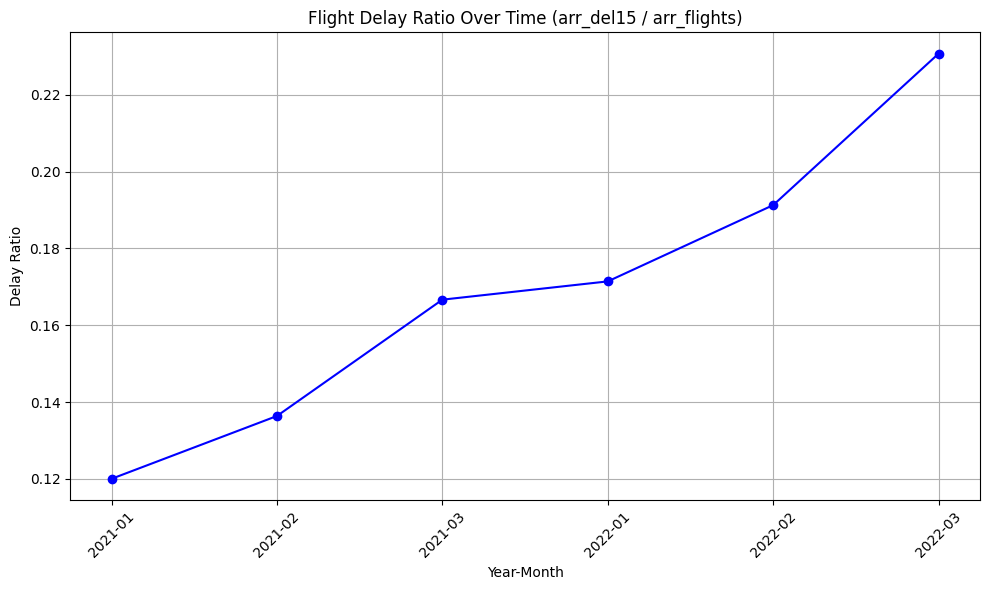

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, sum

try:
    # In a real scenario, you would load your data here:
    # df = spark.read.csv('your_data.csv', header=True, inferSchema=True)

    # Creating sample data to demonstrate the plot
    from pyspark.sql import Row
    data = [
        Row(year=2021, month=1, arr_del15=120, arr_flights=1000),
        Row(year=2021, month=2, arr_del15=150, arr_flights=1100),
        Row(year=2021, month=3, arr_del15=200, arr_flights=1200),
        Row(year=2022, month=1, arr_del15=180, arr_flights=1050),
        Row(year=2022, month=2, arr_del15=220, arr_flights=1150),
        Row(year=2022, month=3, arr_del15=300, arr_flights=1300)
    ]
    df = spark.createDataFrame(data)

    # 1. Aggregate data by year and month
    delay_trends = df.groupBy("year", "month").agg(
        sum("arr_del15").alias("total_delays"),
        sum("arr_flights").alias("total_flights")
    )

    # 2. Calculate the ratio
    delay_trends = delay_trends.withColumn("delay_ratio", col("total_delays") / col("total_flights"))

    # 3. Convert to Pandas for visualization
    pd_df = delay_trends.orderBy("year", "month").toPandas()
    pd_df['date'] = pd_df['year'].astype(str) + "-" + pd_df['month'].astype(str).str.zfill(2)

    # 4. Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(pd_df['date'], pd_df['delay_ratio'], marker='o', linestyle='-', color='b')
    plt.title('Flight Delay Ratio Over Time (arr_del15 / arr_flights)')
    plt.xlabel('Year-Month')
    plt.ylabel('Delay Ratio')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")

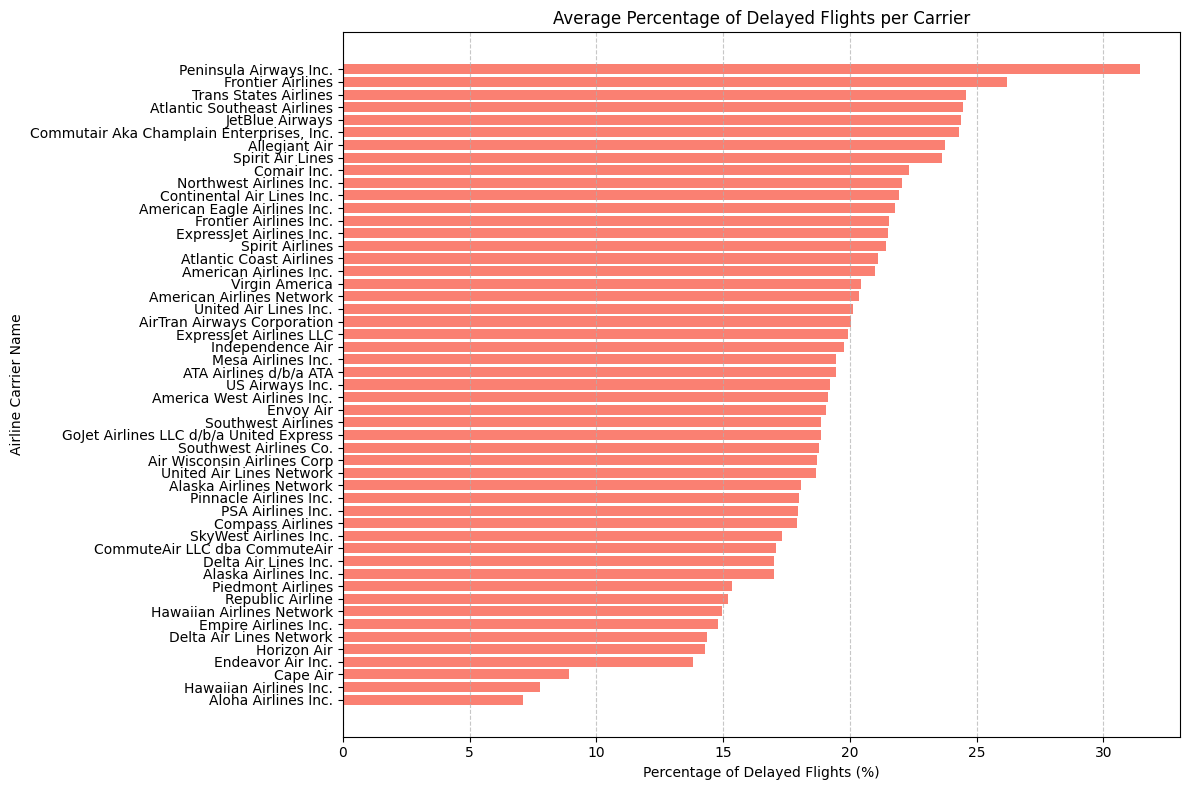

In [11]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, sum

try:
    # Load the actual dataset available in the environment
    file_path = '/content/Airline_Delay_Cause (3).csv'
    df_flights = spark.read.csv(file_path, header=True, inferSchema=True)

    # 1. Calculate delay rate for each record and aggregate by carrier_name
    # Percentage of delayed flights is (Sum of arr_del15 / Sum of arr_flights)
    carrier_delays = df_flights.groupBy("carrier_name").agg(
        sum("arr_del15").alias("total_delays"),
        sum("arr_flights").alias("total_flights")
    )

    # 2. Compute the percentage/rate
    carrier_delays = carrier_delays.withColumn(
        "avg_delay_rate",
        (col("total_delays") / col("total_flights")) * 100
    ).orderBy(col("avg_delay_rate").desc())

    # 3. Convert to Pandas for plotting
    pd_carrier_df = carrier_delays.toPandas()

    # 4. Create the bar chart
    plt.figure(figsize=(12, 8))
    plt.barh(pd_carrier_df['carrier_name'], pd_carrier_df['avg_delay_rate'], color='salmon')
    plt.xlabel('Percentage of Delayed Flights (%)')
    plt.ylabel('Airline Carrier Name')
    plt.title('Average Percentage of Delayed Flights per Carrier')
    plt.gca().invert_yaxis()  # Put highest delays at the top
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error processing carrier data: {e}")

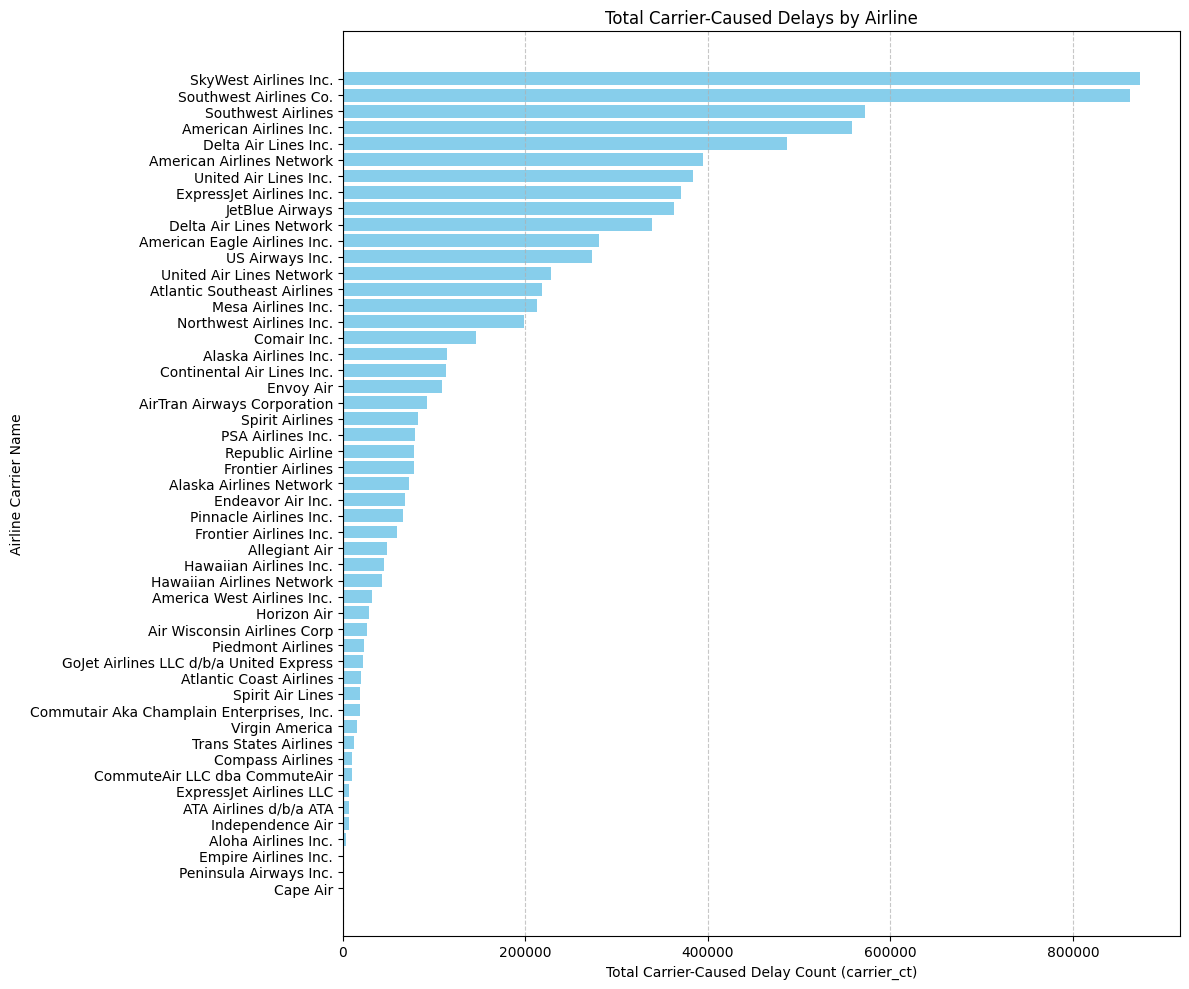

In [12]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum, col

try:
    # 1. Aggregate carrier_ct by airline carrier_name
    carrier_ct_df = df_flights.groupBy("carrier_name").agg(
        sum("carrier_ct").alias("total_carrier_ct")
    ).orderBy(col("total_carrier_ct").desc())

    # 2. Convert to Pandas for plotting
    pd_carrier_ct = carrier_ct_df.toPandas()

    # 3. Create the bar chart
    plt.figure(figsize=(12, 10))
    plt.barh(pd_carrier_ct['carrier_name'], pd_carrier_ct['total_carrier_ct'], color='skyblue')
    plt.xlabel('Total Carrier-Caused Delay Count (carrier_ct)')
    plt.ylabel('Airline Carrier Name')
    plt.title('Total Carrier-Caused Delays by Airline')
    plt.gca().invert_yaxis()  # Highest counts at the top
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

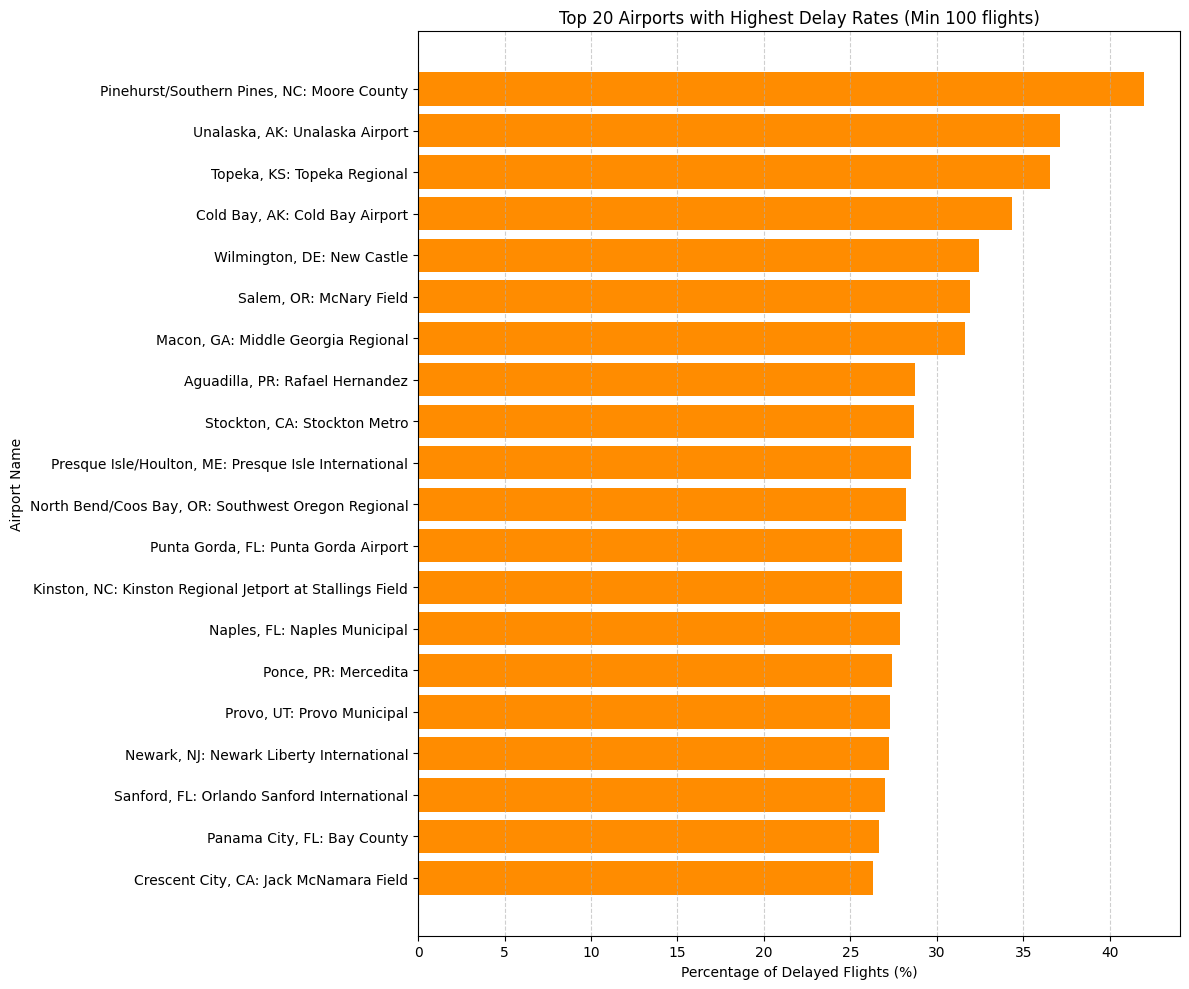

In [13]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, sum

try:
    # 1. Aggregate delays and flights by airport
    airport_delays = df_flights.groupBy("airport", "airport_name").agg(
        sum("arr_del15").alias("total_delays"),
        sum("arr_flights").alias("total_flights")
    )

    # 2. Filter out airports with very low flight counts to avoid statistical outliers (e.g., 1 flight/1 delay = 100%)
    # We'll set a minimum of 100 total flights for this analysis.
    airport_delays = airport_delays.filter(col("total_flights") >= 100)

    # 3. Calculate the delay rate
    airport_delays = airport_delays.withColumn(
        "delay_rate",
        (col("total_delays") / col("total_flights")) * 100
    ).orderBy(col("delay_rate").desc())

    # 4. Take the top 20 for a clear visualization
    pd_airport_delays = airport_delays.limit(20).toPandas()

    # 5. Plotting
    plt.figure(figsize=(12, 10))
    plt.barh(pd_airport_delays['airport_name'], pd_airport_delays['delay_rate'], color='darkorange')
    plt.xlabel('Percentage of Delayed Flights (%)')
    plt.ylabel('Airport Name')
    plt.title('Top 20 Airports with Highest Delay Rates (Min 100 flights)')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred during airport analysis: {e}")

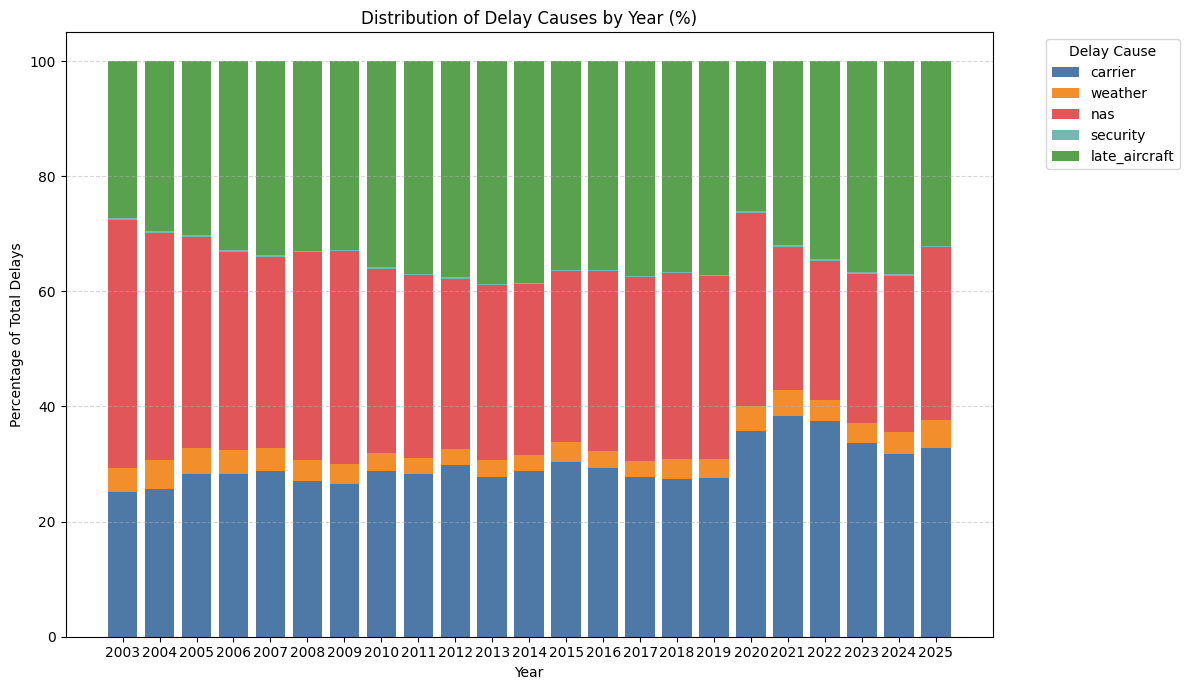

In [14]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum, col

try:
    # 1. Define the cause columns
    cause_cols = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']

    # 2. Aggregate counts by year
    yearly_causes = df_flights.groupBy("year").agg(
        *[sum(c).alias(c) for c in cause_cols]
    ).orderBy("year").toPandas()

    # 3. Calculate percentages for each year (normalization)
    yearly_causes['total'] = yearly_causes[cause_cols].sum(axis=1)
    for col_name in cause_cols:
        yearly_causes[col_name + '_pct'] = (yearly_causes[col_name] / yearly_causes['total']) * 100

    # 4. Plotting stacked bar chart
    plt.figure(figsize=(12, 7))
    years = yearly_causes['year'].astype(str)
    bottom = None

    colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']

    for i, col_name in enumerate(cause_cols):
        pct_col = col_name + '_pct'
        plt.bar(years, yearly_causes[pct_col], bottom=bottom, label=col_name.replace('_ct', ''), color=colors[i])
        if bottom is None:
            bottom = yearly_causes[pct_col].values
        else:
            bottom += yearly_causes[pct_col].values

    plt.title('Distribution of Delay Causes by Year (%)')
    plt.xlabel('Year')
    plt.ylabel('Percentage of Total Delays')
    plt.legend(title='Delay Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred during cause analysis: {e}")

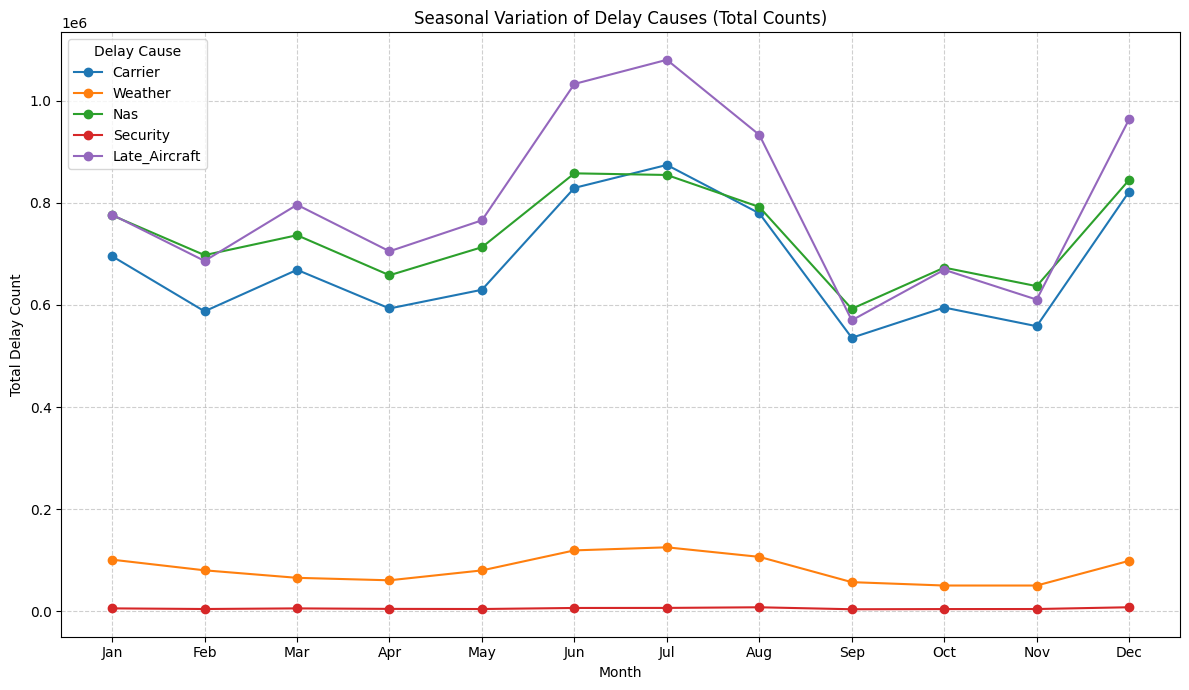

In [15]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum, col

try:
    # 1. Define the cause columns we want to track
    cause_cols = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']

    # 2. Aggregate counts by month
    seasonal_causes = df_flights.groupBy("month").agg(
        *[sum(c).alias(c) for c in cause_cols]
    ).orderBy("month").toPandas()

    # 3. Plotting the multi-line chart
    plt.figure(figsize=(12, 7))

    # Define month labels for clarity
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    for cause in cause_cols:
        plt.plot(seasonal_causes['month'], seasonal_causes[cause], marker='o', label=cause.replace('_ct', '').title())

    plt.title('Seasonal Variation of Delay Causes (Total Counts)')
    plt.xlabel('Month')
    plt.ylabel('Total Delay Count')
    plt.xticks(range(1, 13), month_labels)
    plt.legend(title='Delay Cause')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred during seasonal analysis: {e}")

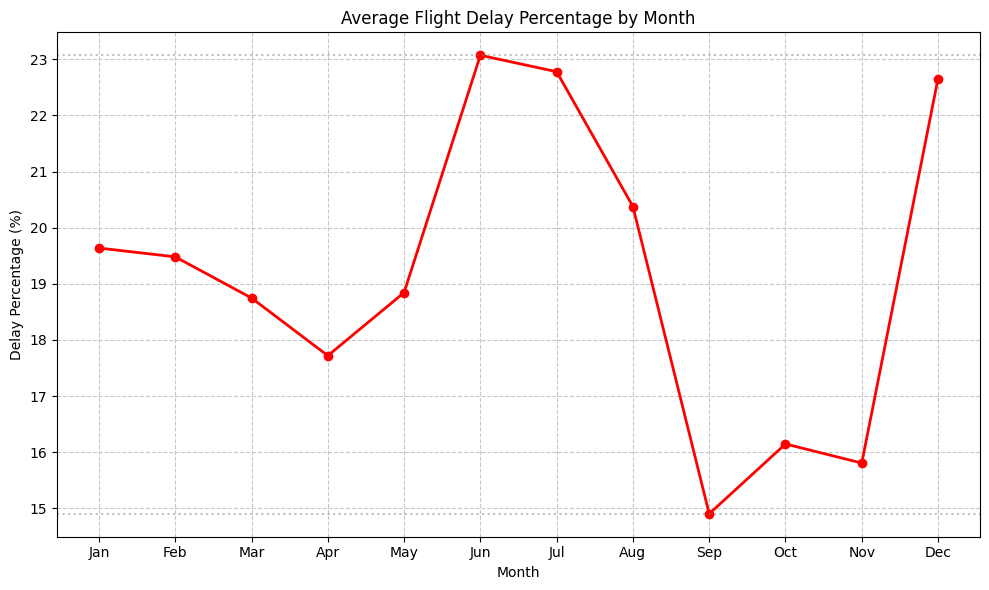

In [16]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum, col

try:
    # 1. Aggregate total delays and total flights by month
    monthly_stats = df_flights.groupBy("month").agg(
        sum("arr_del15").alias("total_delays"),
        sum("arr_flights").alias("total_flights")
    )

    # 2. Calculate the delay percentage
    monthly_stats = monthly_stats.withColumn(
        "delay_percentage",
        (col("total_delays") / col("total_flights")) * 100
    ).orderBy("month")

    # 3. Convert to Pandas for visualization
    pd_monthly_stats = monthly_stats.toPandas()

    # 4. Plotting
    plt.figure(figsize=(10, 6))
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    plt.plot(pd_monthly_stats['month'], pd_monthly_stats['delay_percentage'], marker='o', linewidth=2, color='red')

    plt.title('Average Flight Delay Percentage by Month')
    plt.xlabel('Month')
    plt.ylabel('Delay Percentage (%)')
    plt.xticks(range(1, 13), month_names)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlight peaks and troughs
    max_val = pd_monthly_stats['delay_percentage'].max()
    min_val = pd_monthly_stats['delay_percentage'].min()
    plt.axhline(max_val, color='gray', linestyle=':', alpha=0.5)
    plt.axhline(min_val, color='gray', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred during monthly analysis: {e}")